In [1]:
import numpy as np
from pathlib import Path
import os, json, sys
import matplotlib.pyplot as plt
cwd = Path.cwd()
import seaborn as sns

from groupBMC.groupBMC import GroupBMC

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [2]:
os.getcwd()

'/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder'

Active late
Protected exceedance probabilities: [3.19781873e-04 1.41172241e-02 9.85562994e-01]
                   contrast  delta  ci_low  ci_high  t(19)  n_pos  n_neg     p_raw    p_maxT
        Gain Fixed - Linear  31.33   23.56    39.96  7.214     20      0 1.907e-06 1.907e-06
    Gain Modulated - Linear  38.68    28.7    50.36  6.872     20      0 1.907e-06 3.815e-06
Gain Modulated - Gain Fixed  7.346   -1.97    15.41  1.602     14      6    0.1257    0.2549


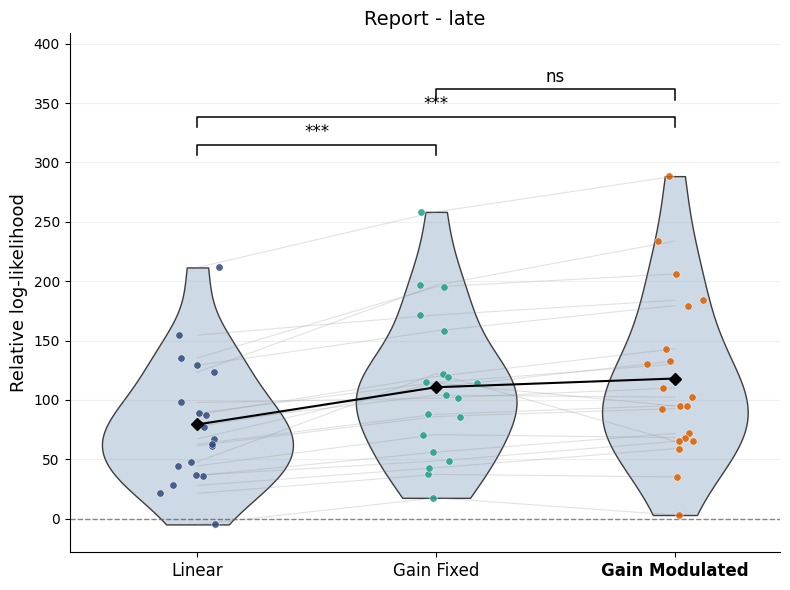

Active early
Protected exceedance probabilities: [0.00282437 0.92833842 0.06883721]
                   contrast  delta  ci_low  ci_high  t(19)  n_pos  n_neg     p_raw    p_maxT
        Gain Fixed - Linear   11.9   4.758    21.95  2.585     18      2 4.959e-05  0.005985
    Gain Modulated - Linear  3.153   1.539    5.237  3.273     17      3 0.0001087 0.0001087
Gain Modulated - Gain Fixed -8.752  -19.27   -1.183 -1.804      6     14   0.04165    0.1409


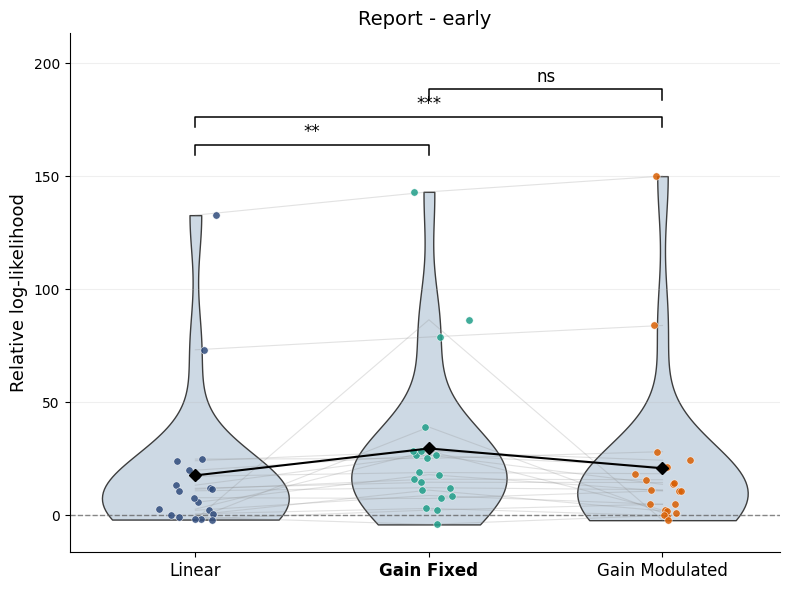

Passive late
Protected exceedance probabilities: [3.32426735e-04 1.53019772e-02 9.84365596e-01]
                   contrast  delta  ci_low  ci_high  t(19)  n_pos  n_neg     p_raw    p_maxT
        Gain Fixed - Linear  24.46   19.07    30.44  8.162     20      0 1.907e-06 1.907e-06
    Gain Modulated - Linear  28.82   22.28    36.17  7.955     20      0 1.907e-06 1.907e-06
Gain Modulated - Gain Fixed  4.362  0.3711    8.259  2.114     15      5   0.04879   0.09978


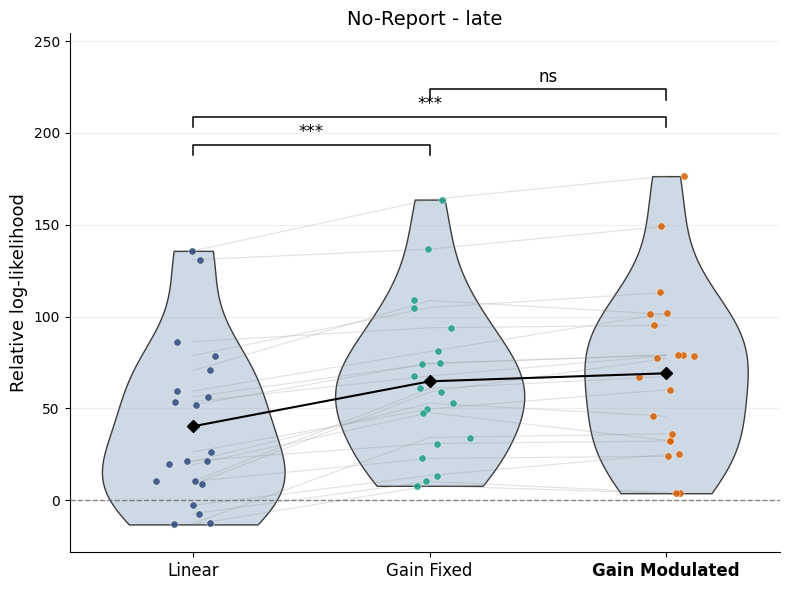

Passive early
Protected exceedance probabilities: [0.00484842 0.98783414 0.00731744]
                   contrast  delta  ci_low  ci_high  t(19)  n_pos  n_neg     p_raw   p_maxT
        Gain Fixed - Linear  6.004   3.064    9.002  3.848     16      4 0.0006351 0.001787
    Gain Modulated - Linear  0.873 -0.1144    1.907  1.667      9     11    0.1122   0.2324
Gain Modulated - Gain Fixed -5.131  -8.477   -1.918 -2.955      6     14  0.006657  0.01813


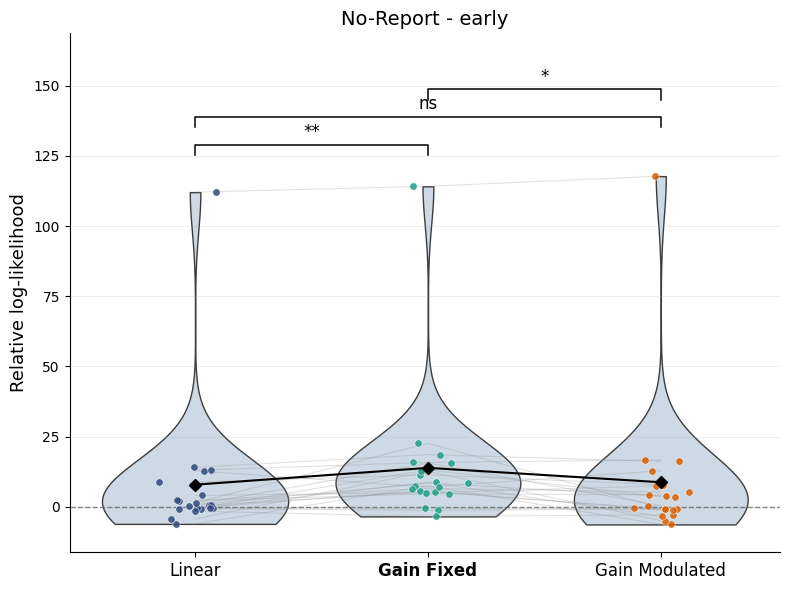

In [8]:
import pandas as pd

checkpoints = [('Active', 'late', f'5CV_Active_late.json'),
               ('Active', 'early', f'5CV_Active_early.json'),
               ('Passive', 'late', f'5CV_Passive_late.json'),
               ('Passive', 'early', f'5CV_Passive_early.json')]


def paired_t(mean, ss, n):
    var = np.maximum((ss - n * mean ** 2) / (n - 1), 0.0)
    se = np.sqrt(var / n)
    with np.errstate(divide='ignore', invalid='ignore'):
        t = np.where(se > 0, mean / np.where(se > 0, se, 1.0), np.sign(mean) * np.inf)
    return np.where(ss == 0, 0.0, t)


def sign_flips(n, exact=True, n_permutations=100000, seed=42, chunk=2 ** 16):
    if exact:
        bits = np.arange(n, dtype=np.int64)
        for start in range(0, 2 ** n, chunk):
            idx = np.arange(start, min(start + chunk, 2 ** n), dtype=np.int64)[:, None]
            yield (1 - 2 * ((idx >> bits) & 1)).astype(float)
    else:
        rng = np.random.default_rng(seed)
        done = 0
        while done < n_permutations:
            m = min(chunk, n_permutations - done)
            signs = rng.choice([-1.0, 1.0], size=(m, n))
            if done == 0:
                signs[0] = 1.0
            done += m
            yield signs


def signflip_maxT(diffs, stepdown=False, exact=True, n_permutations=100000, seed=42):
    D = np.column_stack([np.asarray(d, dtype=float) for d in diffs])
    n, k = D.shape
    ss = (D ** 2).sum(0)
    t_obs = paired_t(D.mean(0), ss, n)
    a_obs = np.abs(t_obs) * (1 - 1e-10)
    order = np.argsort(-np.abs(t_obs), kind='stable')
    a_sorted = a_obs[order]
    count_raw, count_corr, total = np.zeros(k), np.zeros(k), 0
    for signs in sign_flips(n, exact=exact, n_permutations=n_permutations, seed=seed):
        a = np.abs(paired_t(signs @ D / n, ss, n))
        count_raw += (a >= a_obs).sum(0)
        a = a[:, order]
        if stepdown:
            null_max = np.maximum.accumulate(a[:, ::-1], axis=1)[:, ::-1]
        else:
            null_max = np.repeat(a.max(1, keepdims=True), k, axis=1)
        count_corr += (null_max >= a_sorted).sum(0)
        total += signs.shape[0]
    p_sorted = count_corr / total
    if stepdown:
        p_sorted = np.maximum.accumulate(p_sorted)
    p_corr = np.empty(k)
    p_corr[order] = np.minimum(p_sorted, 1.0)
    return t_obs, count_raw / total, p_corr


def bootstrap_ci(diffs, n_boot=10000, level=0.95, seed=42):
    D = np.column_stack([np.asarray(d, dtype=float) for d in diffs])
    rng = np.random.default_rng(seed)
    means = D[rng.integers(0, D.shape[0], (n_boot, D.shape[0]))].mean(1)
    return np.percentile(means, [50 * (1 - level), 50 * (1 + level)], axis=0)


def p_to_stars(p):
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'


maxt_stepdown = False
exact_permutations = True
plot_scale = globals().get('plot_scale', 'delta_from_linear')
stats_tables = {}

for (task, stage, checkpoint_path) in checkpoints:
    print(task, stage)

    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)
    detailed = checkpoint["detailed"]

    linear_ll, nonlinear_ll, gainmodul_ll = [], [], []
    for detail in detailed:
        linear_ll.append(detail['ll_linear_mean'])
        nonlinear_ll.append(detail['ll_nonlinear_mean'])
        gainmodul_ll.append(detail['ll_gainmod_mean'])

    # same for the null model (to delete once the null and other models are merged in the same json)
    with open(checkpoint_path.replace('.json', '_OnlyNull.json'), "r") as f:
        null_checkpoint = json.load(f)
    null_detailed = null_checkpoint["detailed"]
    null_ll = [detail['ll_null_mean'] for detail in null_detailed]

    linear_ll = np.asarray(linear_ll, dtype=float)
    nonlinear_ll = np.asarray(nonlinear_ll, dtype=float)
    gainmodul_ll = np.asarray(gainmodul_ll, dtype=float)
    null_ll = np.asarray(null_ll, dtype=float)
    L = np.array([linear_ll, nonlinear_ll, gainmodul_ll])

    result = GroupBMC(L).get_result()
    print('Protected exceedance probabilities:', result.protected_exceedance_probability)

    ll_arrays_plot = [linear_ll - null_ll, nonlinear_ll - null_ll, gainmodul_ll - null_ll]
    model_order = ['Linear', 'Gain Fixed', 'Gain Modulated']
    x_positions = np.arange(3)
    pair_defs = [(0, 1), (0, 2), (1, 2)]

    diffs = [ll_arrays_plot[j] - ll_arrays_plot[i] for i, j in pair_defs]
    t_obs, raw_pvals, corrected_pvals = signflip_maxT(diffs, stepdown=maxt_stepdown, exact=exact_permutations)
    ci_low, ci_high = bootstrap_ci(diffs)
    stats_tables[(task, stage)] = pd.DataFrame({
        'contrast': [f'{model_order[j]} - {model_order[i]}' for i, j in pair_defs],
        'delta': [d.mean() for d in diffs],
        'ci_low': ci_low,
        'ci_high': ci_high,
        't(19)': t_obs,
        'n_pos': [(d > 0).sum() for d in diffs],
        'n_neg': [(d < 0).sum() for d in diffs],
        'p_raw': raw_pvals,
        'p_maxT': corrected_pvals,
    })
    print(stats_tables[(task, stage)].to_string(index=False, float_format=lambda v: f'{v:.4g}'))

    fig, ax = plt.subplots(figsize=(8, 6))

    violin_arrays = [np.asarray(v, dtype=float) for v in ll_arrays_plot]
    violin_arrays[0] = violin_arrays[0] + np.linspace(-1e-9, 1e-9, len(violin_arrays[0]))
    sns.violinplot(
        data=violin_arrays,
        inner=None,
        cut=0,
        linewidth=1.0,
        ax=ax,
        color='#c9d9e8'
    )

    baseline = 0.0 if plot_scale == 'delta_from_linear' else 1.0
    ax.axhline(baseline, color='0.35', ls='--', lw=1.0, alpha=0.7)

    for subj_idx in range(len(linear_ll)):
        subj_vals = [ll_arrays_plot[0][subj_idx], ll_arrays_plot[1][subj_idx], ll_arrays_plot[2][subj_idx]]
        ax.plot(x_positions, subj_vals, color='0.55', alpha=0.25, lw=0.8, zorder=1)

    condition_means = [np.mean(vals) for vals in ll_arrays_plot]
    ax.plot(
        x_positions,
        condition_means,
        color='black',
        marker='D',
        markersize=6,
        linewidth=1.5,
        zorder=4
    )

    rng = np.random.default_rng(42)
    jitter = 0.08
    point_colors = ['#2f4b7c', '#1f9e89', '#d95f02'][:len(ll_arrays_plot)]
    for x, vals, c in zip(x_positions, ll_arrays_plot, point_colors):
        xj = x + rng.normal(0.0, jitter, size=len(vals))
        ax.scatter(xj, vals, s=28, alpha=0.85, color=c, edgecolors='white', linewidths=0.4, zorder=3)

    plot_min = np.min(np.concatenate(ll_arrays_plot))
    plot_max = np.max(np.concatenate(ll_arrays_plot))
    if plot_scale == 'delta_from_linear':
        plot_min = min(plot_min, baseline)
        plot_max = max(plot_max, baseline)
    plot_span = max(plot_max - plot_min, 1e-6)
    y_base = plot_max + 0.06 * plot_span
    y_step = 0.08 * plot_span
    h = 0.03 * plot_span

    for k, ((i, j), p_corr) in enumerate(zip(pair_defs, corrected_pvals)):
        y = y_base + k * y_step
        ax.plot([i, i, j, j], [y, y + h, y + h, y], color='black', lw=1.1, zorder=4)
        ax.text((i + j) / 2, y + h + 0.01 * plot_span, p_to_stars(p_corr), ha='center', va='bottom', fontsize=12)

    y_top = y_base + len(pair_defs) * y_step + h + 0.08 * plot_span
    ax.set_ylim(plot_min - 0.08 * plot_span, y_top)
    ax.set_xticks(x_positions)
    tick_labels = ax.set_xticklabels(model_order, fontsize=12)
    best_model_idx = int(np.argmax(condition_means))
    for tick_idx, tick in enumerate(ax.xaxis.get_major_ticks()):
        tick.label1.set_fontweight('bold' if tick_idx == best_model_idx else 'normal')
    y_label = 'Relative log-likelihood'
    ax.set_ylabel(y_label, fontsize=13)
    task_names_for_plot = {'Active': 'Report', 'Passive': 'No-Report'}
    ax.set_title(f'{task_names_for_plot[task]} - {stage}', fontsize=14)
    ax.grid(axis='y', alpha=0.2)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(f'Results_EEG_v3/Population_LL_Comparison_{task}_{stage}_delta_from_null.png', dpi=300)
    plt.show()

In [11]:
# Compute the number of data points used to get the LL of 
# each model for each subject, task, and analysis period.

import warnings

windows = {'early': 10, 'late': 25}
n_rest_chunks, rest_len = 5, 50

n_heldout_samples = {}
for task in ['Active', 'Passive']:
    counts = []
    for sub in SubIDs:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            state_series = lead.STG(repo_root.parents[0] / f'myEpochs_{task}/Epoch_{sub}-epo.fif', tmin=300, tmax=500)
        k = len(state_series) - 1
        n_min = min(v.shape[0] for v in state_series.values())
        counts.append((k, n_min))
    for stage, w in windows.items():
        n_heldout_samples[(task, stage)] = np.array(
            [n_min * (k * (w - 1) + (rest_len - 1) * (n_rest_chunks + k)) / 5 for k, n_min in counts])

for c, v in n_heldout_samples.items():
    print(c, v.round(1))

('Active', 'early') [14231. 15087. 15622. 14873. 14873. 15515. 15301. 14980. 16050. 16264.
 13589. 15943. 15515. 16478. 16371. 16692. 16585. 16799. 15943. 16264.]
('Active', 'late') [16226. 17202. 17812. 16958. 16958. 17690. 17446. 17080. 18300. 18544.
 15494. 18178. 17690. 18788. 18666. 19032. 18910. 19154. 18178. 18544.]
('Passive', 'early') [15515.  15408.  15729.  15408.  14017.  16371.  15943.  14659.  14124.
 15729.  16604.  17434.2 18027.2 16604.  18383.  18145.8 18264.4 17790.
 16485.4 18027.2]
('Passive', 'late') [17690.  17568.  17934.  17568.  15982.  18666.  18178.  16714.  16104.
 17934.  19124.  20080.2 20763.2 19124.  21173.  20899.8 21036.4 20490.
 18987.4 20763.2]


In [12]:
model_keys = {'Linear': 'll_linear_mean', 'Gain Fixed': 'll_nonlinear_mean', 'Gain Modulated': 'll_gainmod_mean'}
model_pairs = [('Gain Fixed', 'Linear'), ('Gain Modulated', 'Linear'), ('Gain Modulated', 'Gain Fixed')]
cells_order = [('Passive', 'early'), ('Passive', 'late'), ('Active', 'early'), ('Active', 'late')]
anova_term = {'period': 'period x model', 'task': 'task x model', 'period x task': 'task x period x model'}
maxt_stepdown = False
exact_permutations = True

ll_cells = {}
for task, stage, checkpoint_path in checkpoints:
    with open(checkpoint_path, 'r') as f:
        detailed = json.load(f)['detailed']
    df = pd.DataFrame({m: [d[k] for d in detailed] for m, k in model_keys.items()},
                      index=[str(d.get('part', d.get('participant'))) for d in detailed], dtype=float)
    if n_heldout_samples is not None:
        df = df / np.reshape(np.asarray(n_heldout_samples[(task, stage)], dtype=float), (-1, 1))
    ll_cells[(task, stage)] = df

subjects = sorted(set.intersection(*(set(df.index) for df in ll_cells.values())))
missing = {c: sorted(set(df.index) - set(subjects)) for c, df in ll_cells.items() if set(df.index) - set(subjects)}
if missing:
    raise ValueError(f'Unbalanced design, subjects missing from some conditions: {missing}')
ll_cells = {c: df.loc[subjects] for c, df in ll_cells.items()}
n_subj = len(subjects)


def contrasts_2x2(cells):
    ne, nl, re_, rl = (cells[c] for c in cells_order)
    omnibus = {'period': ((nl + rl) - (ne + re_)) / 2,
               'task': ((re_ + rl) - (ne + nl)) / 2,
               'period x task': (rl - re_) - (nl - ne)}
    simple = {'late - early | no-report': nl - ne,
              'late - early | report': rl - re_,
              'report - no-report | early': re_ - ne,
              'report - no-report | late': rl - nl}
    return omnibus, simple


def effects_table(contrasts):
    labels, diffs = list(contrasts), list(contrasts.values())
    t_obs, p_raw, p_corr = signflip_maxT(diffs, stepdown=maxt_stepdown, exact=exact_permutations)
    ci_low, ci_high = bootstrap_ci(diffs)
    return pd.DataFrame({
        'effect': labels,
        'delta': [d.mean() for d in diffs],
        'ci_low': ci_low,
        'ci_high': ci_high,
        f't({n_subj - 1})': t_obs,
        f'F(1,{n_subj - 1})': t_obs ** 2,
        'n_pos': [(d > 0).sum() for d in diffs],
        'n_neg': [(d < 0).sum() for d in diffs],
        'p_raw': p_raw,
        'p_maxT': p_corr,
        'stars': [p_to_stars(p) for p in p_corr],
    })


omnibus_contrasts, simple_tables = {}, []
for a, b in model_pairs:
    d = {c: ll_cells[c][a].to_numpy() - ll_cells[c][b].to_numpy() for c in cells_order}
    omnibus, simple = contrasts_2x2(d)
    omnibus_contrasts.update({f'{a} - {b} | {anova_term[k]}': v for k, v in omnibus.items()})
    simple_tables.append(effects_table({f'{a} - {b} | {k}': v for k, v in simple.items()}))

omnibus_table = effects_table(omnibus_contrasts)
simple_table = pd.concat(simple_tables, ignore_index=True)

fmt = lambda v: f'{v:.4g}'
units = 'nats / held-out sample' if n_heldout_samples is not None else 'nats (mean test-fold log-likelihood, not normalized)'
print(f'Model x condition effects: exact sign-flip tests on paired t, {"step-down" if maxt_stepdown else "single-step"} max-T')
print(f'{n_subj} subjects; delta in {units}')
print()
print(f'Omnibus effects (max-T across the {len(omnibus_table)} tests)')
print(omnibus_table.to_string(index=False, float_format=fmt))
print()
print('Simple effects (max-T across the 4 tests of each model pair)')
print(simple_table.to_string(index=False, float_format=fmt))

Model x condition effects: exact sign-flip tests on paired t, single-step max-T
20 subjects; delta in nats / held-out sample

Omnibus effects (max-T across the 9 tests)
                                             effect      delta     ci_low   ci_high   t(19)  F(1,19)  n_pos  n_neg     p_raw    p_maxT stars
               Gain Fixed - Linear | period x model  0.0009337  0.0005464  0.001323   4.558    20.78     17      3  0.000288 0.0007973   ***
                 Gain Fixed - Linear | task x model  0.0004658  9.303e-05 0.0008996    2.18    4.752     15      5   0.03158    0.2198    ns
        Gain Fixed - Linear | task x period x model  2.525e-05 -0.0008292 0.0007866 0.06073 0.003688     11      9    0.9545         1    ns
           Gain Modulated - Linear | period x model   0.001705   0.001366  0.002071   9.302    86.53     20      0 1.907e-06 1.907e-06   ***
             Gain Modulated - Linear | task x model  0.0003903  0.0001175 0.0007023   2.564    6.573     16      4   0.01371  

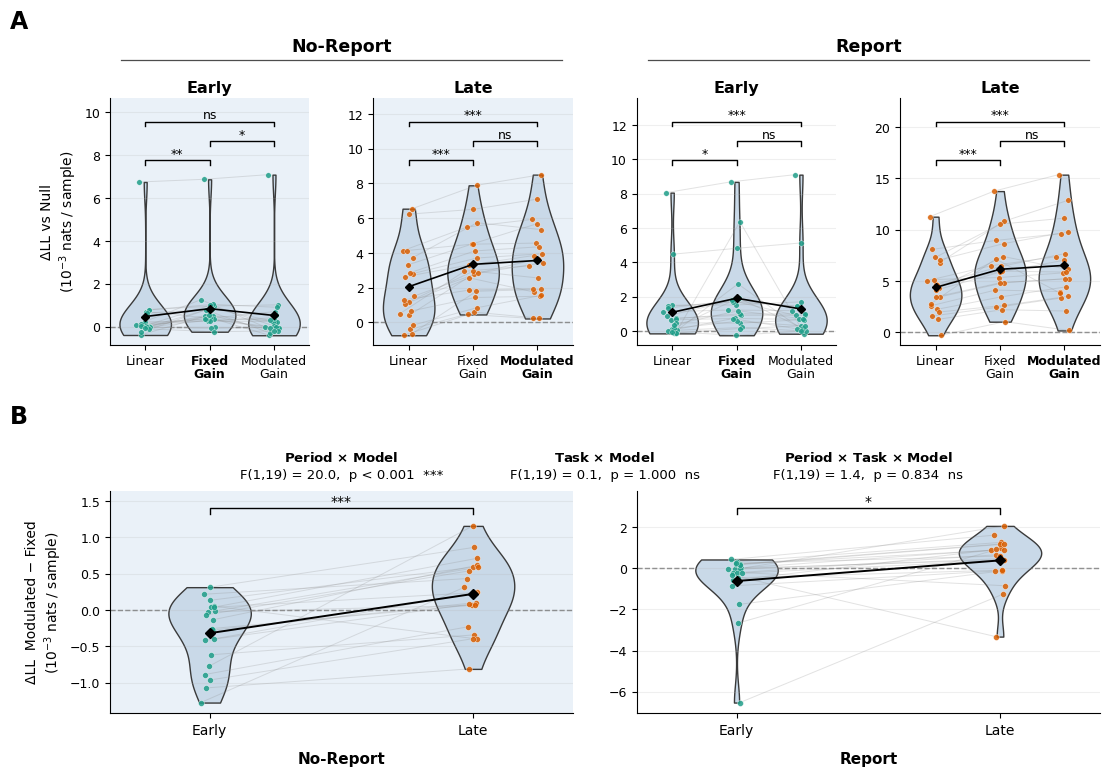

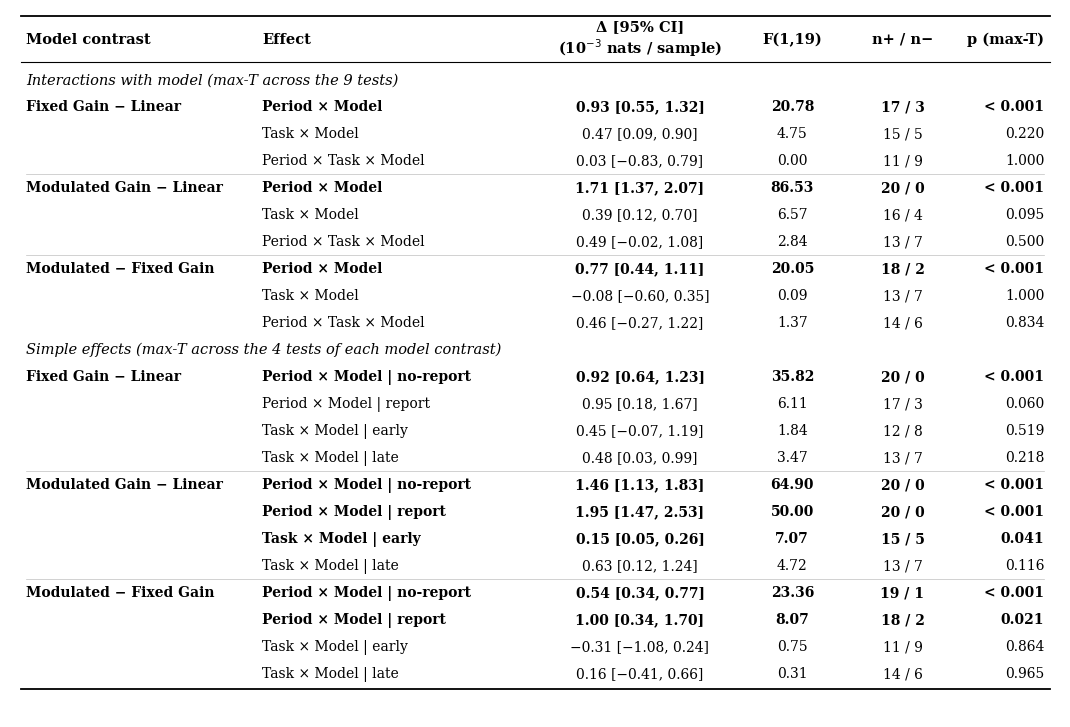

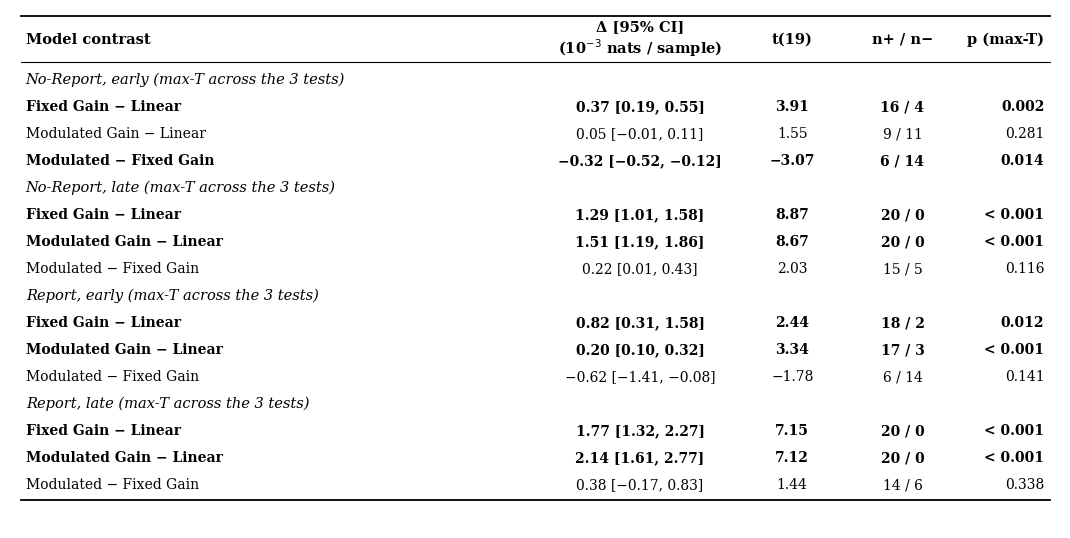

In [18]:
from pathlib import Path
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

model_order = ['Linear', 'Gain Fixed', 'Gain Modulated']
model_ticks = {'Linear': 'Linear', 'Gain Fixed': 'Fixed Gain', 'Gain Modulated': 'Modulated Gain'}
bms_winner = {'early': 'Gain Fixed', 'late': 'Gain Modulated'}
row_order = ['Passive', 'Active']
row_names = {'Passive': 'NO REPORT', 'Active': 'REPORT'}
group_names = {'Passive': 'No-Report', 'Active': 'Report'}
period_colors = {'early': '#1f9e89', 'late': '#d95f02'}
no_report_bg = '#eaf1f8'
violin_fill = '#c9d9e8'
units = 'nats / sample' if n_heldout_samples is not None else 'nats'
out_dir = Path('Results_EEG_v3')
contrast_names = {'Gain Fixed - Linear': 'Fixed Gain − Linear',
                  'Gain Modulated - Linear': 'Modulated Gain − Linear',
                  'Gain Modulated - Gain Fixed': 'Modulated − Fixed Gain'}
effect_names = {'period x model': 'Period × Model',
                'task x model': 'Task × Model',
                'task x period x model': 'Period × Task × Model',
                'late - early | no-report': 'Period × Model | no-report',
                'late - early | report': 'Period × Model | report',
                'report - no-report | early': 'Task × Model | early',
                'report - no-report | late': 'Task × Model | late'}

null_cells = {}
for task, stage, checkpoint_path in checkpoints:
    with open(checkpoint_path.replace('.json', '_OnlyNull.json'), 'r') as f:
        null_detailed = json.load(f)['detailed']
    s = pd.Series([d['ll_null_mean'] for d in null_detailed],
                  index=[str(d.get('part', d.get('participant'))) for d in null_detailed], dtype=float)
    if n_heldout_samples is not None:
        s = s / np.asarray(n_heldout_samples[(task, stage)], dtype=float)
    null_cells[(task, stage)] = s.loc[subjects].to_numpy()

pair_defs = [('Linear', 'Gain Fixed'), ('Linear', 'Gain Modulated'), ('Gain Fixed', 'Gain Modulated')]
pairwise_rows = []
for c in cells_order:
    diffs = [ll_cells[c][b].to_numpy() - ll_cells[c][a].to_numpy() for a, b in pair_defs]
    t_obs, p_raw, p_corr = signflip_maxT(diffs, stepdown=maxt_stepdown, exact=exact_permutations)
    ci_low, ci_high = bootstrap_ci(diffs)
    for k, (a, b) in enumerate(pair_defs):
        pairwise_rows.append({'task': c[0], 'period': c[1], 'contrast': f'{b} - {a}',
                              'delta': diffs[k].mean(), 'ci_low': ci_low[k], 'ci_high': ci_high[k],
                              f't({n_subj - 1})': t_obs[k], 'n_pos': (diffs[k] > 0).sum(),
                              'n_neg': (diffs[k] < 0).sum(), 'p_raw': p_raw[k], 'p_maxT': p_corr[k]})
pairwise_table = pd.DataFrame(pairwise_rows)


def pick_exp(values):
    m = np.nanmax(np.abs(np.asarray(values, dtype=float)))
    return 0 if m == 0 or not np.isfinite(m) else int(3 * np.floor(np.log10(m) / 3))


def unit_label(exp):
    return units if exp == 0 else f'10$^{{{exp}}}$ {units}'


def fmt_num(v, exp=0):
    return f'{v * 10.0 ** (-exp):.2f}'.replace('-', '−')


exp_a = pick_exp([ll_cells[c][m].to_numpy() - null_cells[c] for c in cells_order for m in model_order])
exp_b = pick_exp([ll_cells[c]['Gain Modulated'].to_numpy() - ll_cells[c]['Gain Fixed'].to_numpy() for c in cells_order])
exp_int = pick_exp(pd.concat([omnibus_table, simple_table])[['delta', 'ci_low', 'ci_high']].to_numpy())
exp_pair = pick_exp(pairwise_table[['delta', 'ci_low', 'ci_high']].to_numpy())


def fmt_p(p):
    return '< 0.001' if p < 1e-3 else f'{p:.3f}'


def bracket(ax, x1, x2, y, h, text, fontsize=10):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color='black', lw=1.0, zorder=5, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=fontsize)


def violins(ax, arrays, positions, width):
    for x, v in zip(positions, arrays):
        v = np.asarray(v, dtype=float)
        v = v + np.linspace(-1e-9, 1e-9, len(v)) if np.ptp(v) == 0 else v
        body = ax.violinplot([v], positions=[x], widths=width, showextrema=False)['bodies'][0]
        body.set_facecolor(violin_fill)
        body.set_edgecolor('#3a3a3a')
        body.set_linewidth(1.0)
        body.set_alpha(1.0)
        body.set_zorder(1)


def panel_models(ax, task, stage, jitter):
    vals = [(ll_cells[(task, stage)][m].to_numpy() - null_cells[(task, stage)]) * 10.0 ** (-exp_a) for m in model_order]
    x = np.arange(3)
    if task == 'Passive':
        ax.set_facecolor(no_report_bg)
    ax.axhline(0.0, color='0.35', ls='--', lw=1.0, alpha=0.7, zorder=0.5)
    violins(ax, vals, x, 0.8)
    for i in range(n_subj):
        ax.plot(x + jitter[i], [v[i] for v in vals], color='0.55', alpha=0.25, lw=0.7, zorder=2)
    for xi, v in zip(x, vals):
        ax.scatter(xi + jitter, v, s=16, alpha=0.85, color=period_colors[stage],
                   edgecolors='white', linewidths=0.3, zorder=3)
    ax.plot(x, [v.mean() for v in vals], color='black', marker='D', markersize=4.5, linewidth=1.2, zorder=4)
    lo, hi = min(0.0, min(v.min() for v in vals)), max(v.max() for v in vals)
    span = max(hi - lo, 1e-12)
    sub = pairwise_table[(pairwise_table.task == task) & (pairwise_table.period == stage)]
    bracket_level = {('Linear', 'Gain Fixed'): 0, ('Gain Fixed', 'Gain Modulated'): 1, ('Linear', 'Gain Modulated'): 2}
    for a, b in pair_defs:
        p = sub.loc[sub.contrast == f'{b} - {a}', 'p_maxT'].item()
        i, j = model_order.index(a), model_order.index(b)
        bracket(ax, i, j, hi + (0.06 + 0.12 * bracket_level[(a, b)]) * span, 0.03 * span, p_to_stars(p), fontsize=9)
    ax.set_ylim(lo - 0.06 * span, hi + 0.48 * span)
    ax.set_xlim(-0.55, 2.55)
    ax.set_xticks(x)
    ax.set_xticklabels([model_ticks[m].replace(' ', '\n') for m in model_order], fontsize=9, linespacing=1.0)
    for tick, m in zip(ax.get_xticklabels(), model_order):
        tick.set_fontweight('bold' if m == bms_winner[stage] else 'normal')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', alpha=0.2)
    sns.despine(ax=ax)


def panel_stimulus_dependence(axes_b, xs_local, jitter, vwidth):
    pair = 'Gain Modulated - Gain Fixed'
    d = {c: (ll_cells[c]['Gain Modulated'].to_numpy() - ll_cells[c]['Gain Fixed'].to_numpy()) * 10.0 ** (-exp_b) for c in cells_order}
    simple_label = {'Passive': 'late - early | no-report', 'Active': 'late - early | report'}
    for ax, task in zip(axes_b, row_order):
        e, l = d[(task, 'early')], d[(task, 'late')]
        xe, xl = xs_local
        if task == 'Passive':
            ax.set_facecolor(no_report_bg)
        ax.axhline(0.0, color='0.35', ls='--', lw=1.0, alpha=0.7, zorder=0.5)
        violins(ax, [e, l], xs_local, vwidth)
        for i in range(n_subj):
            ax.plot([xe + jitter[i], xl + jitter[i]], [e[i], l[i]], color='0.55', alpha=0.25, lw=0.7, zorder=2)
        for x, v, stage in [(xe, e, 'early'), (xl, l, 'late')]:
            ax.scatter(x + jitter, v, s=18, alpha=0.85, color=period_colors[stage],
                       edgecolors='white', linewidths=0.3, zorder=3)
        ax.plot([xe, xl], [e.mean(), l.mean()], color='black', marker='D', markersize=5.5, linewidth=1.4, zorder=4)
        lo, hi = min(0.0, e.min(), l.min()), max(e.max(), l.max())
        span = max(hi - lo, 1e-12)
        p = simple_table.loc[simple_table.effect == f'{pair} | {simple_label[task]}', 'p_maxT'].item()
        bracket(ax, xe, xl, hi + 0.07 * span, 0.03 * span, p_to_stars(p), fontsize=10)
        ax.set_ylim(lo - 0.06 * span, hi + 0.2 * span)
        ax.set_xlim(0.0, 1.0)
        ax.set_xticks(xs_local)
        ax.set_xticklabels(['Early', 'Late'], fontsize=10)
        ax.tick_params(axis='y', labelsize=9)
        ax.text(0.5, -0.17, group_names[task], transform=ax.transAxes, ha='center', va='top',
                fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.2)
        sns.despine(ax=ax)
    axes_b[0].set_ylabel(f'ΔLL  Modulated − Fixed\n({unit_label(exp_b)})', fontsize=10)


jitter = np.random.default_rng(42).normal(0.0, 0.07, n_subj)
fig = plt.figure(figsize=(11, 7.6))
outer = GridSpec(2, 1, height_ratios=[1.0, 0.9], hspace=0.62, figure=fig, left=0.09, right=0.99, top=0.88, bottom=0.07)
grid_a = GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[0], wspace=0.32)
axes_a = []
for k, (task, stage) in enumerate(cells_order):
    ax = fig.add_subplot(grid_a[0, k])
    panel_models(ax, task, stage, jitter)
    ax.set_title(stage.title(), fontsize=11.5, fontweight='bold', pad=4)
    axes_a.append(ax)
axes_a[0].set_ylabel(f'ΔLL vs Null\n({unit_label(exp_a)})', fontsize=10)
boxes = [a.get_position() for a in axes_a]
for (i, j), task in [((0, 1), 'Passive'), ((2, 3), 'Active')]:
    fig.text((boxes[i].x0 + boxes[j].x1) / 2, boxes[0].y1 + 0.055, group_names[task],
             ha='center', va='bottom', fontsize=12.5, fontweight='bold')
    fig.add_artist(plt.Line2D([boxes[i].x0 + 0.01, boxes[j].x1 - 0.01], [boxes[0].y1 + 0.05] * 2, color='0.3', lw=0.9))

pb = outer[1].get_position(fig)
axes_b = []
for i, j in [(0, 1), (2, 3)]:
    axes_b.append(fig.add_axes([boxes[i].x0, pb.y0, boxes[j].x1 - boxes[i].x0, pb.height]))
half_width = boxes[1].x1 - boxes[0].x0
xs_local = [((boxes[k].x0 + boxes[k].x1) / 2 - boxes[0].x0) / half_width for k in (0, 1)]
panel_width = (boxes[0].x1 - boxes[0].x0) / half_width
panel_stimulus_dependence(axes_b, xs_local, jitter * panel_width / 3.1, 0.8 * panel_width / 3.1 * 1.6)

pair = 'Gain Modulated - Gain Fixed'
fcol = [c for c in omnibus_table.columns if c.startswith('F(')][0]
rows = omnibus_table[omnibus_table.effect.str.startswith(pair + ' | ')]
header_x = [(boxes[0].x0 + boxes[1].x1) / 2, (boxes[1].x1 + boxes[2].x0) / 2, (boxes[2].x0 + boxes[3].x1) / 2]
for x, (_, r) in zip(header_x, rows.iterrows()):
    term = r['effect'].split(' | ')[-1]
    fig.text(x, pb.y1 + 0.012, f"$\\bf{{{effect_names[term].replace(' ', '~')}}}$\n{fcol} = {r[fcol]:.1f},  {'p < 0.001' if r['p_maxT'] < 1e-3 else 'p = ' + fmt_p(r['p_maxT'])}  {r['stars']}",
             ha='center', va='bottom', fontsize=9.5, linespacing=1.4)
axes_a[0].text(-0.5, 1.28, 'A', transform=axes_a[0].transAxes, fontsize=17, fontweight='bold')
axes_b[0].text(-0.5 * panel_width, 1.3, 'B', transform=axes_b[0].transAxes, fontsize=17, fontweight='bold')
fig.savefig(out_dir / 'Figure8_ModelComparison.png', dpi=300, bbox_inches='tight')
fig.savefig(out_dir / 'Figure8_ModelComparison.pdf', bbox_inches='tight')
plt.show()


def table_sections(tables, exp):
    sections = []
    for title, df, labels in tables:
        rows = []
        for contrast in contrast_names:
            sub = df[df[labels].str.startswith(contrast + ' | ')] if labels == 'effect' else df[df.contrast == contrast]
            for k, (_, r) in enumerate(sub.iterrows()):
                fcol = [c for c in r.index if c.startswith('F(')]
                stat = (f"{r[fcol[0]]:.2f}" if fcol else f"{r[[c for c in r.index if c.startswith('t(')][0]]:.2f}").replace('-', '−')
                rows.append(([contrast_names[contrast] if k == 0 else '',
                              effect_names[r['effect'].split(' | ', 1)[1]] if labels == 'effect'
                              else f"{group_names[r['task']]}, {r['period']}",
                              f"{fmt_num(r['delta'], exp)} [{fmt_num(r['ci_low'], exp)}, {fmt_num(r['ci_high'], exp)}]",
                              stat, f"{r['n_pos']} / {r['n_neg']}", fmt_p(r['p_maxT'])],
                             r['p_maxT'] < 0.05, k == 0 and len(rows) > 0))
        sections.append((title, rows))
    return sections


def render_table(header, sections, stem, col_x, col_ha, width=10.5):
    n_lines = 2 + sum(1 + len(rows) for _, rows in sections)
    line_h = 0.27
    fig = plt.figure(figsize=(width, (n_lines + 1.2) * line_h))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_lines + 1.2)
    rule = lambda y, lw: ax.plot([0.01, 0.99], [y, y], color='black', lw=lw)
    y = n_lines + 0.1
    rule(y + 0.85, 1.3)
    for x, ha, h in zip(col_x, col_ha, header):
        ax.text(x, y, h, ha=ha, va='center', fontsize=10.5, fontweight='bold', linespacing=1.2)
    rule(y - 0.85, 0.8)
    y -= 0.5
    for title, rows in sections:
        y -= 1
        ax.text(0.015, y, title, ha='left', va='center', fontsize=10.5, style='italic')
        for cells, bold, gap in rows:
            y -= 1
            if gap:
                ax.plot([0.015, 0.985], [y + 0.5, y + 0.5], color='0.75', lw=0.5)
            for x, ha, txt in zip(col_x, col_ha, cells):
                ax.text(x, y, txt, ha=ha, va='center', fontsize=10, fontweight='bold' if bold else 'normal')
    rule(y - 0.55, 1.3)
    fig.savefig(out_dir / f'{stem}.png', dpi=300, bbox_inches='tight')
    fig.savefig(out_dir / f'{stem}.pdf', bbox_inches='tight')
    plt.show()


def write_latex(header, sections, stem, align):
    esc = lambda s: s.replace('\n', ' ').replace('%', '\\%').replace('Δ', '$\\Delta$').replace('−', '$-$').replace('×', '$\\times$').replace('<', '$<$').replace('|', '$\\mid$')
    lines = ['\\begin{tabular}{' + align + '}', '\\toprule', ' & '.join(f'\\textbf{{{esc(h)}}}' for h in header) + ' \\\\', '\\midrule']
    for title, rows in sections:
        lines.append(f'\\multicolumn{{{len(header)}}}{{l}}{{\\textit{{{esc(title)}}}}} \\\\')
        for cells, bold, gap in rows:
            if gap:
                lines.append(f'\\cmidrule(lr){{1-{len(header)}}}')
            cells = [f'\\textbf{{{esc(c)}}}' if bold and c else esc(c) for c in cells]
            lines.append(' & '.join(cells) + ' \\\\')
        lines.append('\\midrule' if title != sections[-1][0] else '\\bottomrule')
    lines.append('\\end{tabular}')
    (out_dir / f'{stem}.tex').write_text('\n'.join(lines), encoding='utf-8')


table_rc = {'font.family': 'serif', 'font.serif': ['Times New Roman', 'Times', 'Liberation Serif', 'DejaVu Serif']}
col_x = [0.015, 0.24, 0.6, 0.745, 0.85, 0.985]
col_ha = ['left', 'left', 'center', 'center', 'center', 'right']

supp_interactions = table_sections([
    (f'Interactions with model (max-T across the {len(omnibus_table)} tests)', omnibus_table, 'effect'),
    ('Simple effects (max-T across the 4 tests of each model contrast)', simple_table, 'effect')], exp_int)
header_interactions = ['Model contrast', 'Effect', f'Δ [95% CI]\n({unit_label(exp_int)})', f'F(1,{n_subj - 1})', 'n+ / n−', 'p (max-T)']

supp_pairwise = [(f'{group_names[t]}, {p} (max-T across the 3 tests)', [
    ([contrast_names[r['contrast']], '', f"{fmt_num(r['delta'], exp_pair)} [{fmt_num(r['ci_low'], exp_pair)}, {fmt_num(r['ci_high'], exp_pair)}]",
      f"{r[f't({n_subj - 1})']:.2f}".replace('-', '−'), f"{r['n_pos']} / {r['n_neg']}", fmt_p(r['p_maxT'])], r['p_maxT'] < 0.05, False)
    for _, r in pairwise_table[(pairwise_table.task == t) & (pairwise_table.period == p)].iterrows()])
    for t, p in cells_order]
header_pairwise = ['Model contrast', '', f'Δ [95% CI]\n({unit_label(exp_pair)})', f't({n_subj - 1})', 'n+ / n−', 'p (max-T)']

with plt.rc_context(table_rc):
    render_table(header_interactions, supp_interactions, 'SuppTable_ModelInteractions', col_x, col_ha)
    render_table(header_pairwise, supp_pairwise, 'SuppTable_PairwiseModelComparison', col_x, col_ha)
write_latex(header_interactions, supp_interactions, 'SuppTable_ModelInteractions', 'llcccr')
write_latex(header_pairwise, supp_pairwise, 'SuppTable_PairwiseModelComparison', 'llcccr')
pd.concat([omnibus_table.assign(family='omnibus'), simple_table.assign(family='simple')]).to_csv(out_dir / 'SuppTable_ModelInteractions.csv', index=False)
pairwise_table.to_csv(out_dir / 'SuppTable_PairwiseModelComparison.csv', index=False)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


   task period          model  n_subjects  n_best  pct_best  expected_frequency       pep  is_winner
 Active  early         Linear          20       0         0             0.01588 0.0007998      False
 Active  early     Fixed Gain          20      14        70              0.6658    0.9499       True
 Active  early Modulated Gain          20       6        30              0.3183   0.04934      False
 Active   late         Linear          20       0         0             0.01587  0.000526      False
 Active   late     Fixed Gain          20       6        30              0.3016   0.03469      False
 Active   late Modulated Gain          20      14        70              0.6826    0.9648       True
Passive  early         Linear          20       3        15              0.1021    0.0494      False
Passive  early     Fixed Gain          20      13        65              0.6759    0.8926       True
Passive  early Modulated Gain          20       4        20               0.222   0.05803  

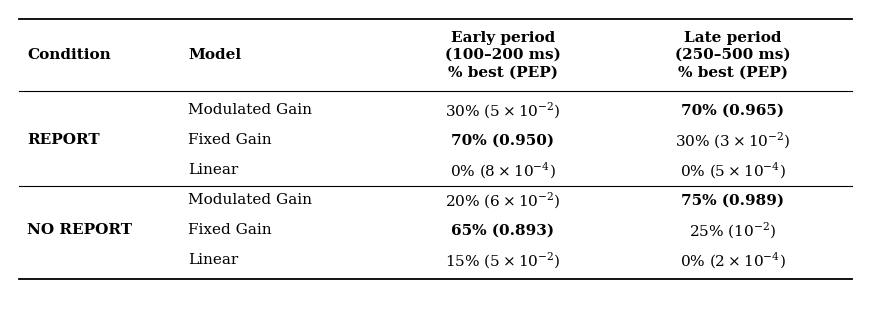

In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from groupBMC.groupBMC import GroupBMC

out_dir = Path('Results_EEG_v3')
model_keys = {'Linear': 'll_linear', 'Fixed Gain': 'll_nonlinear', 'Modulated Gain': 'll_gainmod'}
row_models = ['Modulated Gain', 'Fixed Gain', 'Linear']
tasks = [('Active', 'REPORT'), ('Passive', 'NO REPORT')]
periods = [('early', 'Early period', '100–200 ms'), ('late', 'Late period', '250–500 ms')]


def total_heldout_ll(detail, key):
    folds = detail.get(f'{key}_folds')
    return float(np.sum(folds)) if folds is not None else 5.0 * float(detail[f'{key}_mean'])


rows = []
for task, _ in tasks:
    for period, _, _ in periods:
        with open(f'5CV_{task}_{period}.json', 'r') as f:
            detailed = json.load(f)['detailed']
        L = np.array([[total_heldout_ll(d, key) for d in detailed] for key in model_keys.values()])
        result = GroupBMC(L).get_result()
        pep = np.asarray(result.protected_exceedance_probability, dtype=float).ravel()
        freq = np.asarray(result.frequency_mean, dtype=float).ravel()
        winners = np.argmax(L, axis=0)
        for k, model in enumerate(model_keys):
            rows.append({'task': task, 'period': period, 'model': model, 'n_subjects': L.shape[1],
                         'n_best': int((winners == k).sum()), 'pct_best': 100.0 * (winners == k).mean(),
                         'expected_frequency': freq[k], 'pep': pep[k]})
bms_table = pd.DataFrame(rows)
bms_table['is_winner'] = bms_table.groupby(['task', 'period'])['pep'].transform('max') == bms_table['pep']
print(bms_table.to_string(index=False, float_format=lambda v: f'{v:.4g}'))


def fmt_pep(p, bold=False, latex=False):
    if p >= 0.1:
        return f'{p:.3f}'
    if p <= 0:
        return '0'
    mantissa, exponent = f'{p:.0e}'.split('e')
    core = f'10^{{{int(exponent)}}}' if mantissa == '1' else f'{mantissa} \\times 10^{{{int(exponent)}}}'
    if bold:
        core = f'\\boldsymbol{{{core}}}' if latex else f'\\mathbf{{{core}}}'
    return f'${core}$'


def cell_text(r, bold=False, latex=False):
    pct = f"{r['pct_best']:.0f}\\%" if latex else f"{r['pct_best']:.0f}%"
    return f"{pct} ({fmt_pep(r['pep'], bold, latex)})"


header = ['Condition', 'Model'] + [f'{name}\n({window})\n% best (PEP)' for _, name, window in periods]
body = []
for task, task_label in tasks:
    for k, model in enumerate(row_models):
        cells, cells_tex, bold = [task_label if k == 1 else '', model], [task_label if k == 1 else '', model], [True, False]
        for period, _, _ in periods:
            r = bms_table[(bms_table.task == task) & (bms_table.period == period) & (bms_table.model == model)].iloc[0]
            win = bool(r['is_winner'])
            cells.append(cell_text(r, win))
            cells_tex.append(cell_text(r, win, latex=True))
            bold.append(win)
        body.append((cells, cells_tex, bold, k == 0 and len(body) > 0))

col_x = [0.02, 0.21, 0.58, 0.85]
col_ha = ['left', 'left', 'center', 'center']
line_h = 0.3
n_lines = 3 + len(body)
with plt.rc_context({'font.family': 'serif', 'font.serif': ['Times New Roman', 'Times', 'Liberation Serif', 'DejaVu Serif'],
                     'mathtext.fontset': 'custom', 'mathtext.rm': 'serif', 'mathtext.bf': 'serif:bold'}):
    fig = plt.figure(figsize=(8.5, (n_lines + 1.2) * line_h))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_lines + 1.2)
    rule = lambda y, lw: ax.plot([0.01, 0.99], [y, y], color='black', lw=lw)
    y = n_lines - 0.3
    rule(y + 1.2, 1.3)
    for x, ha, h in zip(col_x, col_ha, header):
        ax.text(x, y, h, ha=ha, va='center', fontsize=11, fontweight='bold', linespacing=1.3)
    rule(y - 1.2, 0.8)
    y -= 0.85
    for cells, _, bold, gap in body:
        y -= 1
        if gap:
            rule(y + 0.5, 0.8)
        for x, ha, txt, b in zip(col_x, col_ha, cells, bold):
            ax.text(x, y, txt, ha=ha, va='center', fontsize=11, fontweight='bold' if b else 'normal')
    rule(y - 0.6, 1.3)
    fig.savefig(out_dir / 'SuppTable1_BMS.png', dpi=300, bbox_inches='tight')
    fig.savefig(out_dir / 'SuppTable1_BMS.pdf', bbox_inches='tight')
    plt.show()

lines = ['\\begin{tabular}{llcc}', '\\toprule',
         '\\textbf{Condition} & \\textbf{Model} & ' + ' & '.join(f'\\textbf{{{name}}}' for _, name, _ in periods) + ' \\\\',
         ' & & ' + ' & '.join(f"({window.replace('–', '--')})" for _, _, window in periods) + ' \\\\',
         ' & & ' + ' & '.join('\\% best (\\textit{PEP})' for _ in periods) + ' \\\\',
         '\\midrule']
for _, cells_tex, bold, gap in body:
    if gap:
        lines.append('\\midrule')
    out = [f'\\textbf{{{c}}}' if (b and c) else c for c, b in zip(cells_tex, bold)]
    lines.append(' & '.join(out) + ' \\\\')
lines += ['\\bottomrule', '\\end{tabular}']
(out_dir / 'SuppTable1_BMS.tex').write_text('\n'.join(lines), encoding='utf-8')
bms_table.to_csv(out_dir / 'SuppTable1_BMS.csv', index=False)